In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# for nicer plots
sns.set(style="whitegrid")
%matplotlib inline

In [8]:
#load Dataset
df = pd.read_csv("../data/sales_data.csv")
df.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2.0,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1.0,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4.0,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3.0,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5.0,8.66,43.30,1.50,41.80,22


In [12]:
# Basic checks
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   float64
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 170.3+ KB


In [13]:
# Quick descriptive statistics
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1980.0,NaN,NaN,NaN,5542.958081,2575.771856,1006.0,3271.5,5582.5,7791.75,9998.0
store_name,1955,9,City Fresh Store,235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transaction_date,1980,689,2023-10-18,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aisle,1980,11,Beverages,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_name,1980,18,Chicken Breast,131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,1980.0,NaN,NaN,NaN,2.968182,1.419028,1.0,2.0,3.0,4.0,5.0
unit_price,1980.0,NaN,NaN,NaN,15.488045,8.400823,0.99,8.24,15.19,22.8625,29.98
total_amount,1980.0,NaN,NaN,NaN,45.902576,35.018599,1.01,18.0,37.13,67.93,149.9
discount_amount,1980.0,NaN,NaN,NaN,4.469591,4.962001,0.0,1.24,3.045,5.4025,29.94
final_amount,1980.0,NaN,NaN,NaN,41.432985,32.593328,-3.43,15.8,32.82,60.8,147.91


In [26]:
df.columns = df.columns.str.strip()  # remove extra spaces
df.columns = df.columns.str.lower()  # lowercase all


In [15]:
#Inspect Data
print("Dataset shape:", df.shape)

Dataset shape: (1980, 11)


In [27]:
print("Columns:", df.columns)

Columns: Index(['customer_id', 'store_name', 'transaction_date', 'aisle',
       'product_name', 'quantity', 'unit_price', 'total_amount',
       'discount_amount', 'final_amount', 'loyalty_points'],
      dtype='object')


In [17]:
print("First 5 rows:\n", df.head())

First 5 rows:
    customer_id         store_name transaction_date           aisle  \
0         2824  GreenGrocer Plaza       2023-08-26         Produce   
1         5506   ValuePlus Market       2024-02-13           Dairy   
2         4657   ValuePlus Market       2023-11-23          Bakery   
3         2679  SuperSave Central       2025-01-13  Snacks & Candy   
4         9935  GreenGrocer Plaza       2023-10-13    Canned Goods   

   product_name  quantity  unit_price  total_amount  discount_amount  \
0         Pasta       2.0        7.46         14.92             0.00   
1        Cheese       1.0        1.85          1.85             3.41   
2        Onions       4.0        7.38         29.52             4.04   
3        Cereal       3.0        5.50         16.50             1.37   
4  Orange Juice       5.0        8.66         43.30             1.50   

   final_amount  loyalty_points  
0         14.92             377  
1         -1.56             111  
2         25.48             3

In [18]:
print("Data Types:\n", df.dtypes)

Data Types:
 customer_id           int64
store_name           object
transaction_date     object
aisle                object
product_name         object
quantity            float64
unit_price          float64
total_amount        float64
discount_amount     float64
final_amount        float64
loyalty_points        int64
dtype: object


In [19]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 customer_id          0
store_name          25
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64


In [20]:
#Summary Statistics
print(df.describe())

       customer_id     quantity   unit_price  total_amount  discount_amount  \
count  1980.000000  1980.000000  1980.000000   1980.000000      1980.000000   
mean   5542.958081     2.968182    15.488045     45.902576         4.469591   
std    2575.771856     1.419028     8.400823     35.018599         4.962001   
min    1006.000000     1.000000     0.990000      1.010000         0.000000   
25%    3271.500000     2.000000     8.240000     18.000000         1.240000   
50%    5582.500000     3.000000    15.190000     37.130000         3.045000   
75%    7791.750000     4.000000    22.862500     67.930000         5.402500   
max    9998.000000     5.000000    29.980000    149.900000        29.940000   

       final_amount  loyalty_points  
count   1980.000000     1980.000000  
mean      41.432985      255.147980  
std       32.593328      146.009333  
min       -3.430000        0.000000  
25%       15.800000      128.000000  
50%       32.820000      265.500000  
75%       60.800000   

In [21]:
#  Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


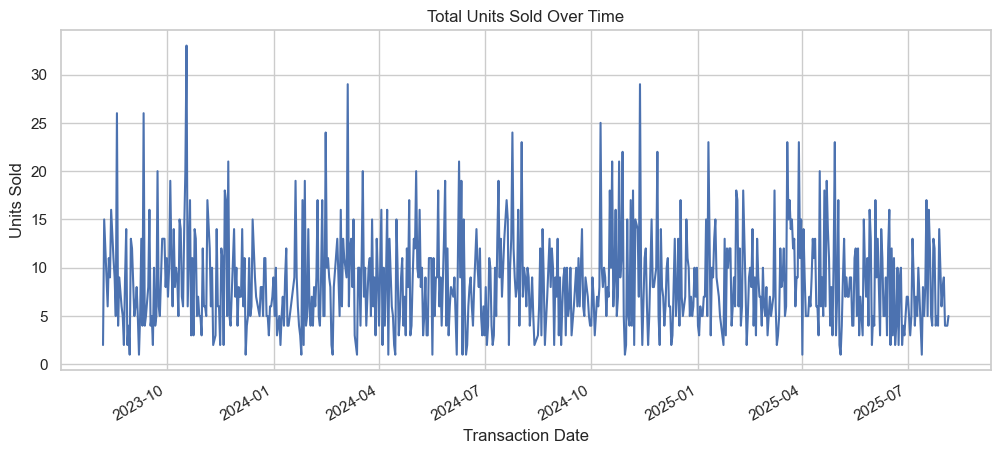

In [31]:
#Sales Overview
# Ensure transaction_date is datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df = df.dropna(subset=['transaction_date'])

# Ensure quantity is numeric
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df = df.dropna(subset=['quantity'])

# Total sales over time
plt.figure(figsize=(12,5))
total_sales = df.groupby('transaction_date')['quantity'].sum()
total_sales.plot()
plt.title("Total Units Sold Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Units Sold")
plt.show()

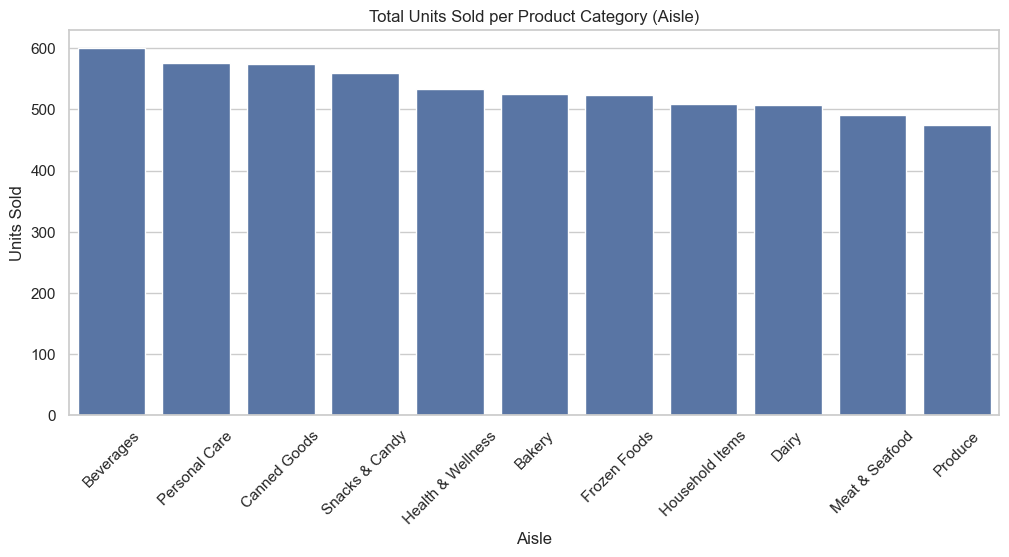

In [33]:
# Sales by Product Category

category_sales = df.groupby('aisle')['quantity'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Units Sold per Product Category (Aisle)")
plt.xlabel("Aisle")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)  # rotate x labels if needed
plt.show()

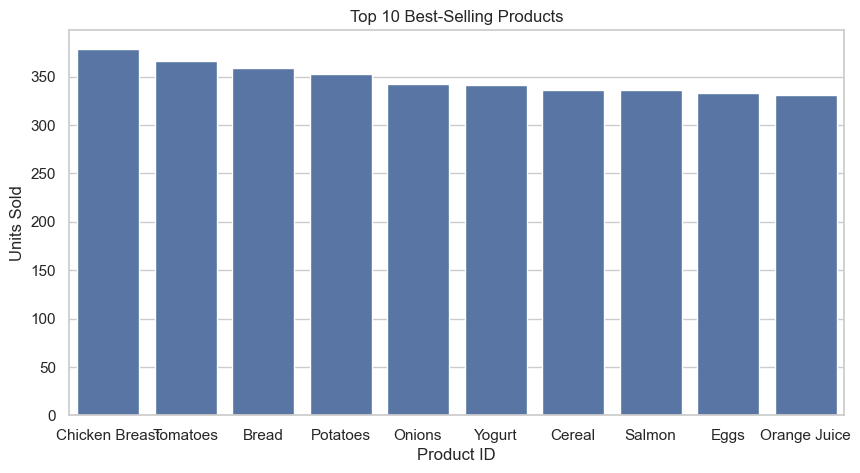

In [35]:
#  Top 10 Best-Selling Products
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_products.index, y=top_products.values)
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Units Sold")
plt.show()

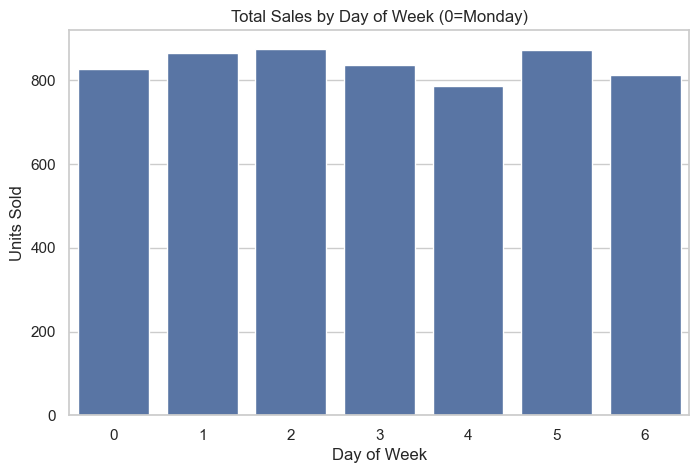

In [37]:
# 9️⃣ Daily Sales Patterns (Seasonality)
df['day_of_week'] = df['transaction_date'].dt.dayofweek
daily_sales = df.groupby('day_of_week')['quantity'].sum()
plt.figure(figsize=(8,5))
sns.barplot(x=daily_sales.index, y=daily_sales.values)
plt.title("Total Sales by Day of Week (0=Monday)")
plt.xlabel("Day of Week")
plt.ylabel("Units Sold")
plt.show()

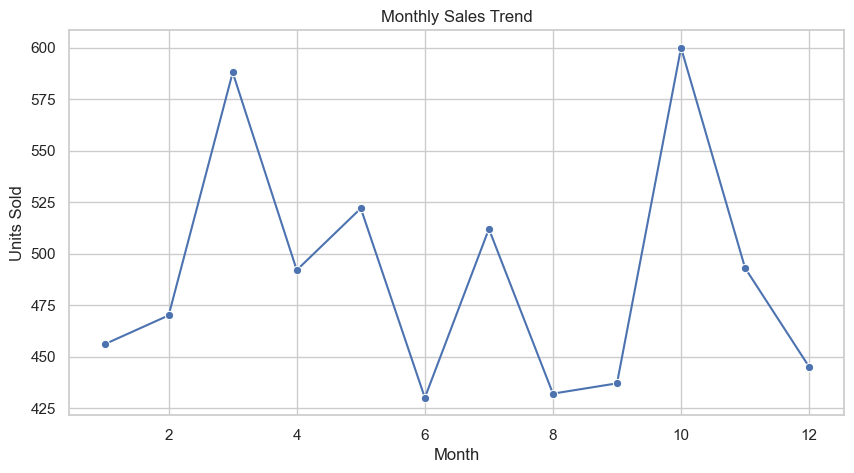

In [39]:
#  Monthly Sales Trends
df['month'] = df['transaction_date'].dt.month
monthly_sales = df.groupby('month')['quantity'].sum()
plt.figure(figsize=(10,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.show()

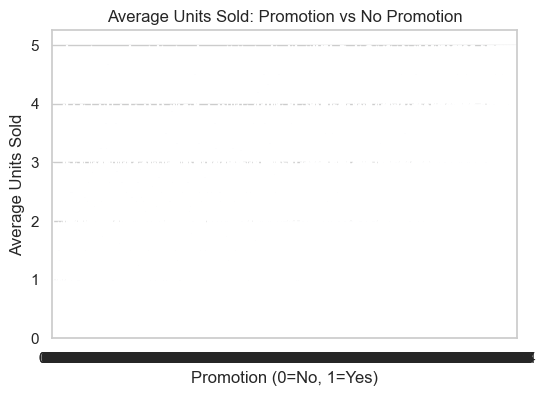

In [41]:
# 1 Impact of Promotions
promo_sales = df.groupby('discount_amount')['quantity'].mean()
plt.figure(figsize=(6,4))
sns.barplot(x=promo_sales.index, y=promo_sales.values)
plt.title("Average Units Sold: Promotion vs No Promotion")
plt.xlabel("Promotion (0=No, 1=Yes)")
plt.ylabel("Average Units Sold")
plt.show()

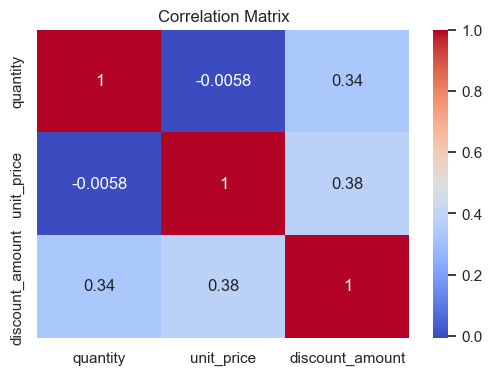

In [45]:
# 1 Correlation Analysis
# Encode promotion as numeric if needed
if df['discount_amount'].dtype == 'object':
    df['discount_amount'] = df['discount_amount'].map({'Yes':1,'No':0})

numeric_features = ['quantity', 'unit_price', 'discount_amount']
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

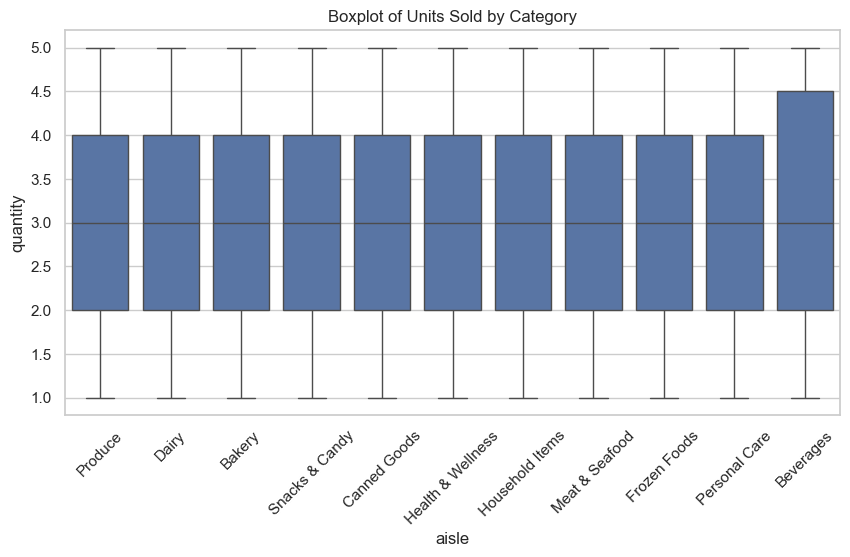

In [47]:
#  Check for Outliers in Units Sold
plt.figure(figsize=(10,5))
sns.boxplot(x='aisle', y='quantity', data=df)
plt.title("Boxplot of Units Sold by Category")
plt.xticks(rotation=45)
plt.show()